<a href="https://colab.research.google.com/github/adrianamalmeida001/projeto-tecnicas-programacao-adatech/blob/main/Projeto_t%C3%A9cnicas_de_programa%C3%A7%C3%A3o.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projeto de tratamento e análise de dados com Pandas – Adatech / CaixaVerso

## Análise de Dados sobre Consumo de Energia

Este projeto tem como objetivo realizar a análise exploratória e o tratamento de dados relacionados ao consumo de energia, utilizando a biblioteca Pandas em Python. O projeto faz parte das atividades do módulo 2 - Técnicas de Programação, promovido pela Adatech em parceria com a Caixa.

Os dados analisados são de fonte pública e abordam informações sobre consumo de energia. Foi utilizada a database do Kaggle disponível em: https://www.kaggle.com/datasets/ibrahimqasimi/owid-energy-data



In [59]:
# importa o pandas e a biblioteca para gráficos
import pandas as pd
import matplotlib.pyplot as plt

In [60]:
# leitura do dataset e mostra as 5 primeiras linhas
df = pd.read_csv("owid-energy-data.csv")
df.head()

,country,year,iso_code,population,gdp,biofuel_cons_change_pct,biofuel_cons_change_twh,biofuel_cons_per_capita,biofuel_consumption,biofuel_elec_per_capita,...,solar_share_elec,solar_share_energy,wind_cons_change_pct,wind_cons_change_twh,wind_consumption,wind_elec_per_capita,wind_electricity,wind_energy_per_capita,wind_share_elec,wind_share_energy
0,ASEAN (Ember),2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
1,ASEAN (Ember),2001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
2,ASEAN (Ember),2002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
3,ASEAN (Ember),2003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
4,ASEAN (Ember),2004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN


In [61]:
# mostra um resumo do dataset, quantidade de linhas e colunas, tipos de variáveis, memória usada.
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23232 entries, 0 to 23231
Columns: 130 entries, country to wind_share_energy
dtypes: float64(127), int64(1), object(2)
memory usage: 23.0+ MB


In [62]:
# faz a contagem de valores nulos
df.isna().sum()


,0
country,0
year,0
iso_code,6098
population,4472
gdp,11452
...,...
wind_elec_per_capita,14995
wind_electricity,13904
wind_energy_per_capita,18087
wind_share_elec,15749


In [63]:
# mostra todos os nomes das colunas
list(df.columns)


['country',
 'year',
 'iso_code',
 'population',
 'gdp',
 'biofuel_cons_change_pct',
 'biofuel_cons_change_twh',
 'biofuel_cons_per_capita',
 'biofuel_consumption',
 'biofuel_elec_per_capita',
 'biofuel_electricity',
 'biofuel_share_elec',
 'biofuel_share_energy',
 'carbon_intensity_elec',
 'coal_cons_change_pct',
 'coal_cons_change_twh',
 'coal_cons_per_capita',
 'coal_consumption',
 'coal_elec_per_capita',
 'coal_electricity',
 'coal_prod_change_pct',
 'coal_prod_change_twh',
 'coal_prod_per_capita',
 'coal_production',
 'coal_share_elec',
 'coal_share_energy',
 'electricity_demand',
 'electricity_demand_per_capita',
 'electricity_generation',
 'electricity_share_energy',
 'energy_cons_change_pct',
 'energy_cons_change_twh',
 'energy_per_capita',
 'energy_per_gdp',
 'fossil_cons_change_pct',
 'fossil_cons_change_twh',
 'fossil_elec_per_capita',
 'fossil_electricity',
 'fossil_energy_per_capita',
 'fossil_fuel_consumption',
 'fossil_share_elec',
 'fossil_share_energy',
 'gas_cons_chan

In [64]:
# cria um dataframe apenas com as colunas que necessito para a análise e mostra o resultado com as 5 primeiras linhas
colunas_projeto = [
    'country',
    'year',
    'population',
    'gdp',
    'primary_energy_consumption',
    'energy_per_capita',
    'fossil_share_energy',
    'renewables_share_energy',
    'solar_share_energy',
    'wind_share_energy',
    'hydro_share_energy'
]

df_tratado = df[colunas_projeto]

df_tratado.head()


,country,year,population,gdp,primary_energy_consumption,energy_per_capita,fossil_share_energy,renewables_share_energy,solar_share_energy,wind_share_energy,hydro_share_energy
0,ASEAN (Ember),2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ASEAN (Ember),2001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ASEAN (Ember),2002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ASEAN (Ember),2003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ASEAN (Ember),2004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [65]:
# conta valores nulos por coluna do dataframe tratado
df_tratado.isna().sum()


,0
country,0
year,0
population,4472
gdp,11452
primary_energy_consumption,9977
energy_per_capita,12146
fossil_share_energy,16853
renewables_share_energy,16853
solar_share_energy,16853
wind_share_energy,16853


In [66]:
# cria um dataframe específico para análise das matrizes energéticas, removendo as linhas onde faltam dados dessas colunas e mostra o número de linhas e colunas que ficaram

df_matriz = df_tratado.dropna(
    subset=[
        'fossil_share_energy',
        'renewables_share_energy',
        'solar_share_energy',
        'wind_share_energy',
        'hydro_share_energy'
    ]
)

df_matriz.shape


(6379, 11)

In [67]:
# criação de um dataframe para vizualizar as colunas traduzidas

# renomeia colunas, fazendo a tradução
df_matriz_pt = df_matriz.rename(columns={
    'country': 'pais',
    'year': 'ano',
    'energy_per_capita': 'energia_per_capita',
    'fossil_share_energy': 'participacao_combustiveis_fosseis',
    'renewables_share_energy': 'participacao_energias_renovaveis',
    'solar_share_energy': 'participacao_energia_solar',
    'wind_share_energy': 'participacao_energia_eolica',
    'hydro_share_energy': 'participacao_energia_hidreletrica'
})

# criação do dataframe para mostrar apenas as colunas traduzidas, mostra o resultado com as 5 primeiras linhas
df_matriz_pt_visual = df_matriz_pt[
    [
        'pais',
        'ano',
        'energia_per_capita',
        'participacao_combustiveis_fosseis',
        'participacao_energias_renovaveis',
        'participacao_energia_solar',
        'participacao_energia_eolica',
        'participacao_energia_hidreletrica'
    ]
]

df_matriz_pt_visual.head()


,pais,ano,energia_per_capita,participacao_combustiveis_fosseis,participacao_energias_renovaveis,participacao_energia_solar,participacao_energia_eolica,participacao_energia_hidreletrica
214,Africa,1965,2228.129,94.581,5.419,0.0,0.0,5.419
215,Africa,1966,2275.300,94.228,5.772,0.0,0.0,5.772
216,Africa,1967,2240.699,94.036,5.964,0.0,0.0,5.964
217,Africa,1968,2306.228,93.395,6.605,0.0,0.0,6.605
218,Africa,1969,2308.462,92.494,7.506,0.0,0.0,7.506


## **PERGUNTA 1** - Como o consumo total de energia evoluiu ao longo dos anos no mundo?

In [68]:
# remove linhas vazias
df_consumo = df_tratado.dropna(subset=['primary_energy_consumption'])

# agrupa os dados por ano
consumo_por_ano = df_consumo.groupby('year')

# soma o consumo de energia de todos os países em cada ano
consumo_mundial_por_ano = consumo_por_ano['primary_energy_consumption'].sum()

# filtra os dados até 2021
consumo_ate_2021 = consumo_mundial_por_ano[consumo_mundial_por_ano.index <= 2021]

# mostra o resultado das 5 primeiras linhas
consumo_ate_2021.head()


,primary_energy_consumption
year,
1965,268637.990
1966,283139.916
1967,293505.182
1968,311176.828
1969,332728.067


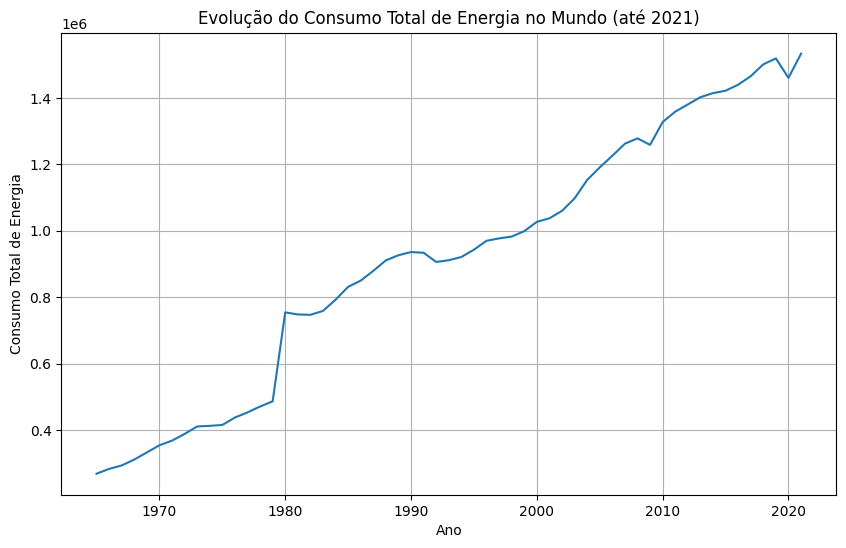

In [69]:
# criação do gráfico de linhas com o resultado
plt.figure(figsize=(10, 6))
plt.plot(consumo_ate_2021)
plt.title("Evolução do Consumo Total de Energia no Mundo (até 2021)")
plt.xlabel("Ano")
plt.ylabel("Consumo Total de Energia")
plt.grid(True)
plt.show()


## **PERGUNTA 2** - Há tendência de crescimento no consumo de energia renovável ao longo dos anos?

In [70]:
# remove linhas vazias
df_renovavel = df_tratado.dropna(subset=['renewables_share_energy'])

# agrupa os dados por ano
renovavel_por_ano = df_renovavel.groupby('year')

# soma a energia renovável de todos os países em cada ano
renovavel_mundial_por_ano = renovavel_por_ano['renewables_share_energy'].sum()

# filtra os dados até 2021
renovavel_ate_2021 = renovavel_mundial_por_ano[renovavel_mundial_por_ano.index <= 2021]

# mostra o resultado das 5 primeiras linhas
renovavel_ate_2021.head()


,renewables_share_energy
year,
1965,811.461
1966,821.114
1967,821.363
1968,820.556
1969,827.001


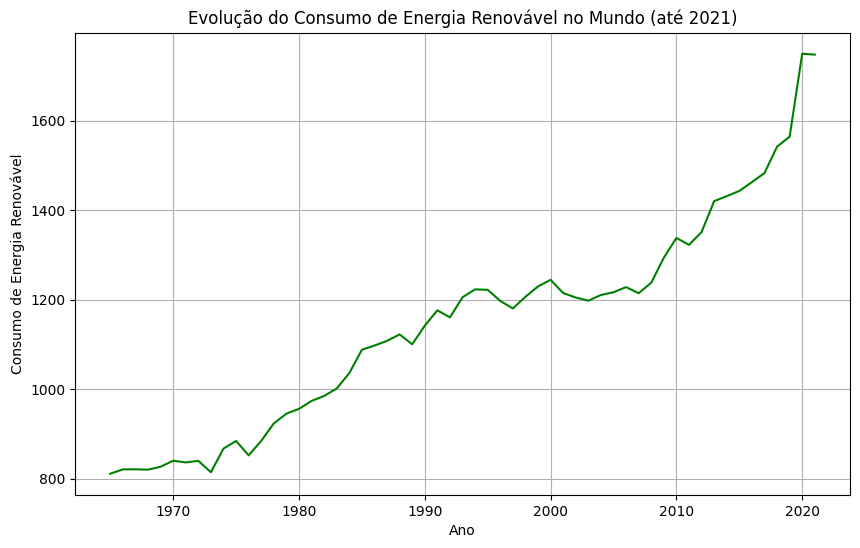

In [71]:
# criação do gráfico de linhas com o resultado
plt.figure(figsize=(10, 6))
plt.plot(renovavel_ate_2021, color='green')
plt.title("Evolução do Consumo de Energia Renovável no Mundo (até 2021)")
plt.xlabel("Ano")
plt.ylabel("Consumo de Energia Renovável")
plt.grid(True)
plt.show()


## **PERGUNTA 3** - Como evoluiu a participação de energia renovável e de energia fóssil no mundo ao longo do tempo?

In [72]:
# agrupa os dados por ano
dados_por_ano = df_matriz.groupby('year')

# seleciona as colunas renováveis e fósseis
fontes_por_ano = dados_por_ano[
    ['renewables_share_energy', 'fossil_share_energy']
]

# calcula a média dessas colunas em cada ano
media_por_ano = fontes_por_ano.mean()

# transforma o resultado em uma coluna
media_por_ano = media_por_ano.reset_index()

# mostra o resultado das 5 primeiras linhas
media_por_ano.head()


,year,renewables_share_energy,fossil_share_energy
0,1965,8.365577,91.582392
1,1966,8.465093,91.468546
2,1967,8.467660,91.458186
3,1968,8.459340,91.455887
4,1969,8.525784,91.363237


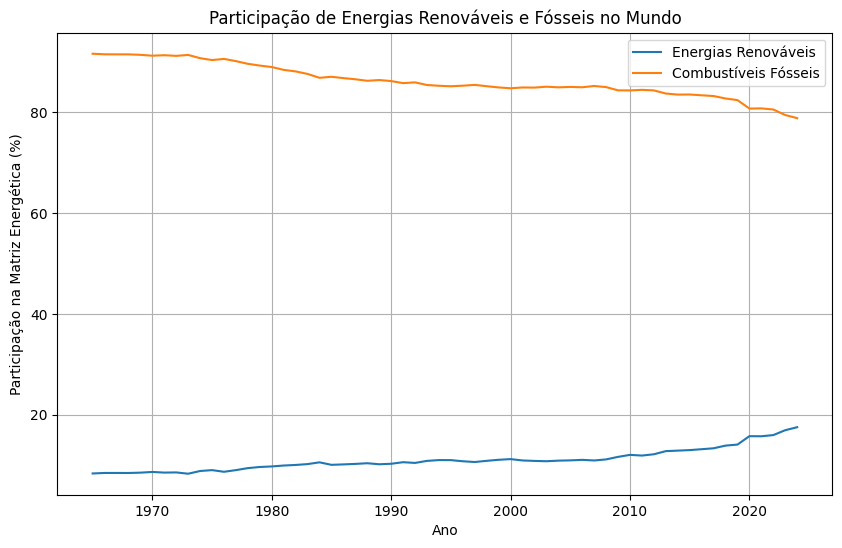

In [73]:
# criação do gráfico de linhas com o resultado
plt.figure(figsize=(10, 6))

plt.plot(
    media_por_ano['year'],
    media_por_ano['renewables_share_energy'],
    label='Energias Renováveis'
)

plt.plot(
    media_por_ano['year'],
    media_por_ano['fossil_share_energy'],
    label='Combustíveis Fósseis'
)

plt.title('Participação de Energias Renováveis e Fósseis no Mundo')
plt.xlabel('Ano')
plt.ylabel('Participação na Matriz Energética (%)')
plt.legend()
plt.grid(True)
plt.show()


## **PERGUNTA 4** - Quais países apresentam maior consumo de energia per capita?

In [74]:
# remove valores nulos
df_per_capita = df_tratado.dropna(subset=['energy_per_capita'])

# agrupa por país
dados_por_pais = df_per_capita.groupby('country')

# calcula a média de energia per capita para cada país
consumo_per_capita_paises = dados_por_pais['energy_per_capita'].mean()

# ordena do maior para o menor
consumo_per_capita_paises_ordenado = consumo_per_capita_paises.sort_values(ascending=False)

# mostra o resultado
top10_per_capita = consumo_per_capita_paises_ordenado.head(10)
top10_per_capita


,energy_per_capita
country,
Netherlands Antilles,280405.755548
United States Virgin Islands,211136.781864
Qatar,185441.816950
Bahrain,148250.522023
United Arab Emirates,124130.426217
Iceland,108331.059817
Canada,106041.422950
Norway,100213.050917
Singapore,98865.235600


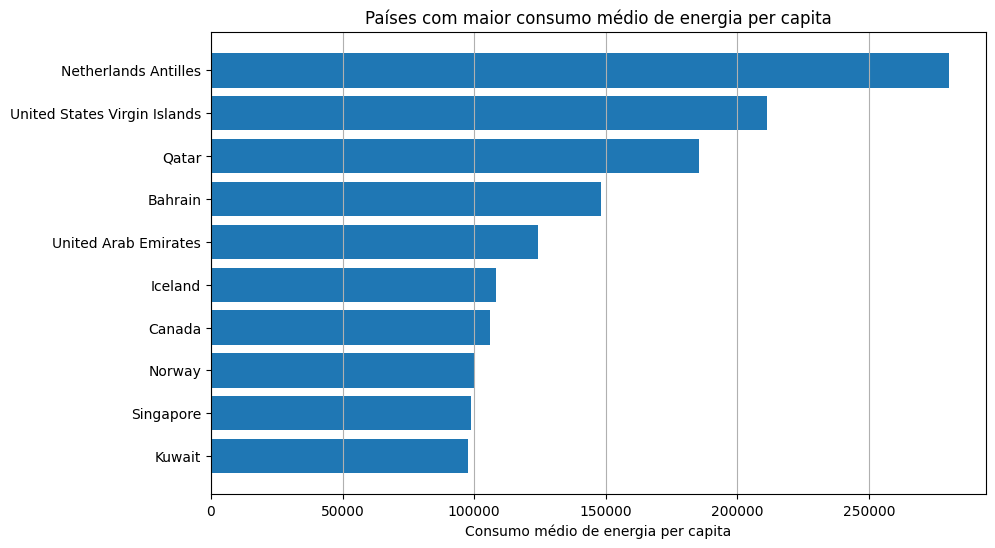

In [75]:
# cria o gráfico de barras com o resultado
plt.figure(figsize=(10, 6))

plt.barh(
    top10_per_capita.index,
    top10_per_capita.values
)

plt.xlabel('Consumo médio de energia per capita')
plt.title('Países com maior consumo médio de energia per capita')
plt.gca().invert_yaxis()
plt.grid(axis='x')

plt.show()


## **PERGUNTA 5** - Os 10 países que mais consomem petróleo concentram que porcentagem do consumo mundial?

In [76]:
# remove valores nulos do consumo de petróleo
df_oil = df.dropna(subset=['oil_consumption'])

# soma o consumo mundial
consumo_mundial_petroleo = df_oil['oil_consumption'].sum()

# calcula o consumo de petrólio por país
consumo_petroleo_paises = (
    df_oil
    .groupby('country')['oil_consumption']
    .sum()
)

# ordena os países do maior para o menor
consumo_petroleo_paises = consumo_petroleo_paises.sort_values(ascending=False)

# seleciona os 10 países que mais consomem
top10_petroleo = consumo_petroleo_paises.head(10)

# soma consumo dos outros países
outros_paises_petroleo = consumo_petroleo_paises.iloc[10:].sum()

# calcula percentual
percentual_top10 = (top10_petroleo.sum() / consumo_mundial_petroleo) * 100
percentual_outros = (outros_paises_petroleo / consumo_mundial_petroleo) * 100

# mostra o resultado
percentual_top10_2 = round(percentual_top10, 2)
percentual_outros_2 = round(percentual_outros, 2)

print("Os 10 países que mais consomem petróleo representam", percentual_top10_2, "% do consumo mundial.")
print("Os demais países representam", percentual_outros_2, "% do consumo mundial.")


Os 10 países que mais consomem petróleo representam 71.17 % do consumo mundial.
Os demais países representam 28.83 % do consumo mundial.


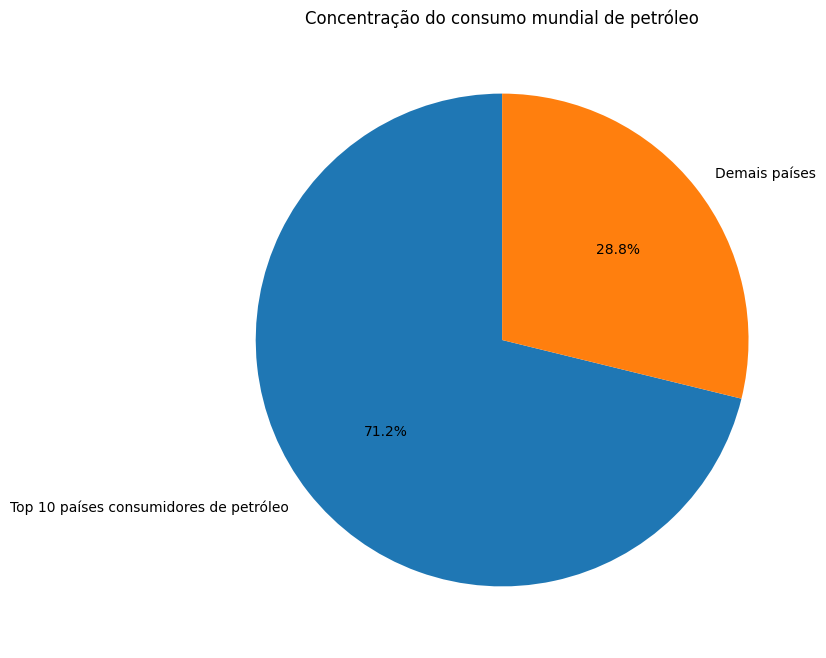

In [77]:
# cria o gráfico de pizza
percentual_top10, percentual_outros

valores = [percentual_top10, percentual_outros]
labels = [
    'Top 10 países consumidores de petróleo',
    'Demais países'
]

plt.figure(figsize=(8, 8))
plt.pie(
    valores,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Concentração do consumo mundial de petróleo')
plt.show()

## **PERGUNTA 6** - Quais países apresentam maior participação média de energias renováveis?

In [78]:
# agrupa os dados por país
dados_por_pais = df_matriz.groupby('country')

# seleção das colunas de análise e cálculo da média
media_paises = dados_por_pais[
    ['renewables_share_energy', 'fossil_share_energy']
].mean()

# ordena os países do maior para o menor
media_ordenada = media_paises.sort_values(
    by='renewables_share_energy',
    ascending=False
)

# seleciona os 10 países com maior participação
top_renovaveis = media_ordenada.head(10)

# mostra o resultado
top10_renovaveis = media_ordenada.head(10)
top10_renovaveis


,renewables_share_energy,fossil_share_energy
country,,
Norway,67.101683,32.898317
Iceland,62.202067,37.797933
Other South America (EI),44.823167,55.176833
New Zealand,38.742750,61.257250
Other CIS (EI),38.682250,58.640925
Brazil,38.033417,61.389783
Sweden,33.848733,45.601200
Switzerland,30.764117,53.907467
Middle Africa (EI),29.341133,70.658867


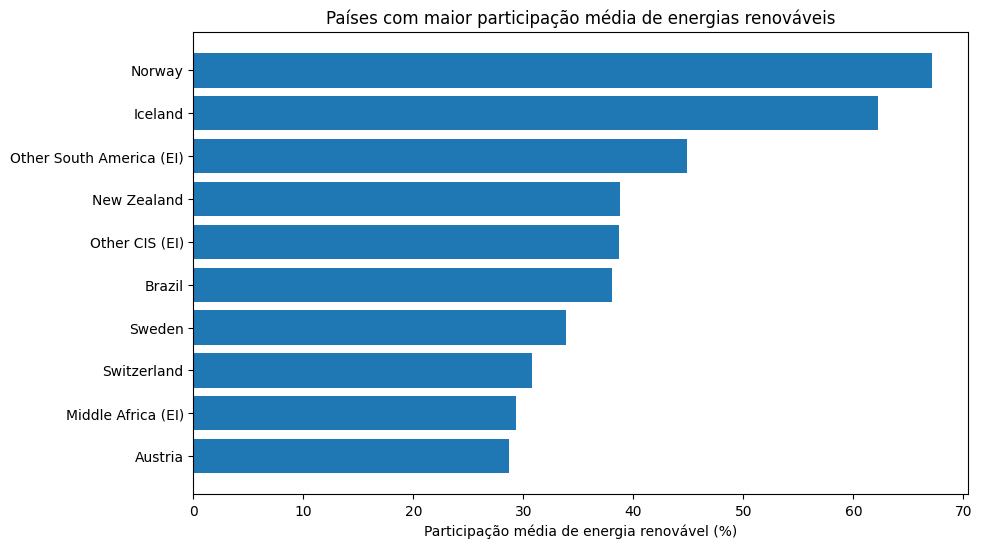

In [79]:
# cria o gráfico de barras com o resultado
plt.figure(figsize=(10, 6))
plt.barh(
    top_renovaveis.index,
    top_renovaveis['renewables_share_energy']
)
plt.xlabel('Participação média de energia renovável (%)')
plt.title('Países com maior participação média de energias renováveis')
plt.gca().invert_yaxis()
plt.show()


## **PERGUNTA 7** - Como a participação de energia renovável do Brasil se compara à média mundial ao longo do tempo?

In [80]:
# seleciona apenas os dados do Brasil
dados_brasil = df_matriz[df_matriz['country'] == 'Brazil']

# seleção do ano e a energia renovável do Brasil
brasil_renovavel = dados_brasil[['year', 'renewables_share_energy']]

# agrupar todos os países por ano
dados_mundo_por_ano = df_matriz.groupby('year')

# calcula a média mundial de energia renovável em cada ano
mundo_renovavel = dados_mundo_por_ano['renewables_share_energy'].mean()

# transforma o resultado em coluna
mundo_renovavel = mundo_renovavel.reset_index()

# unifica os dados do Brasil e do mundo em relação ao ano
comparacao_brasil_mundo = brasil_renovavel.merge(
    mundo_renovavel,
    on='year',
    suffixes=('_Brasil', '_Mundo')
)

# mostra o resultado das 5 primeiras linhas
comparacao_brasil_mundo.head()


,year,renewables_share_energy_Brasil,renewables_share_energy_Mundo
0,1965,26.319,8.365577
1,1966,26.386,8.465093
2,1967,26.641,8.467660
3,1968,24.385,8.459340
4,1969,23.901,8.525784


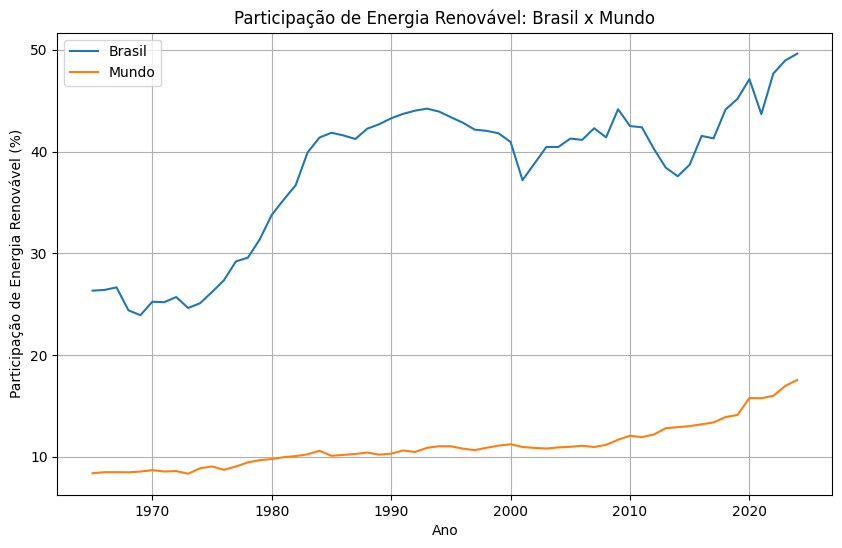

In [81]:
# cria o gráfico de linhas com a comparação
plt.figure(figsize=(10, 6))

plt.plot(
    comparacao_brasil_mundo['year'],
    comparacao_brasil_mundo['renewables_share_energy_Brasil'],
    label='Brasil'
)

plt.plot(
    comparacao_brasil_mundo['year'],
    comparacao_brasil_mundo['renewables_share_energy_Mundo'],
    label='Mundo'
)

plt.title('Participação de Energia Renovável: Brasil x Mundo')
plt.xlabel('Ano')
plt.ylabel('Participação de Energia Renovável (%)')
plt.legend()
plt.grid(True)

plt.show()


## **PERGUNTA 8** - Como a participação de combustíveis fósseis no Brasil se compara com a do mundo ao longo do tempo?

In [82]:
# seleciona apenas as linhas do Brasil
dados_brasil = df_matriz[df_matriz['country'] == 'Brazil']

# seleciona apenas o ano e a participação de combustíveis fósseis
brasil_fosseis = dados_brasil[['year', 'fossil_share_energy']]

# agrupar os dados do mundo por ano
dados_mundo_por_ano = df_matriz.groupby('year')

# calcula a média mundial
mundo_fosseis = dados_mundo_por_ano['fossil_share_energy'].mean()

# transforma o resultado em uma coluna
mundo_fosseis = mundo_fosseis.reset_index()

# unifica os dados do Brasil e do mundo em relação ao ano
comparacao_fosseis = brasil_fosseis.merge(
    mundo_fosseis,
    on='year',
    suffixes=('_Brasil', '_Mundo')
)

# mostra o resultado das 5 primeiras linhas
comparacao_fosseis.head()


,year,fossil_share_energy_Brasil,fossil_share_energy_Mundo
0,1965,73.681,91.582392
1,1966,73.614,91.468546
2,1967,73.359,91.458186
3,1968,75.615,91.455887
4,1969,76.099,91.363237


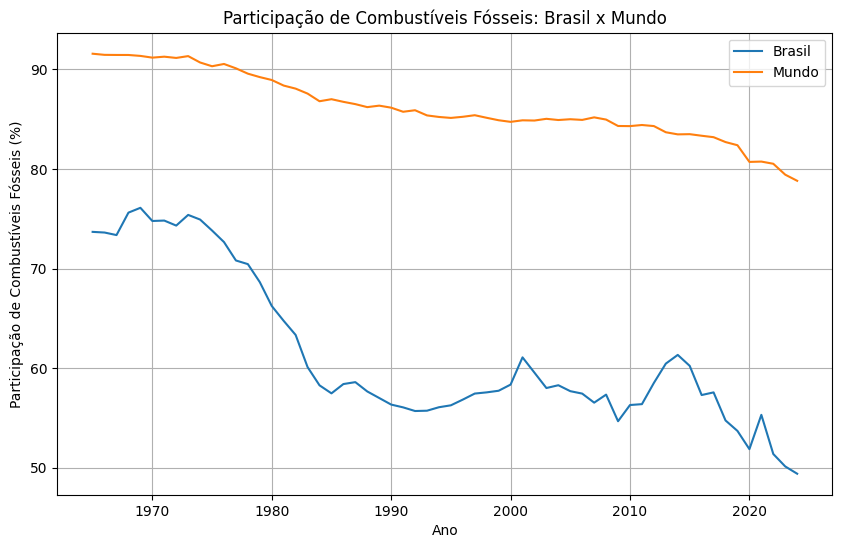

In [83]:
# cria o gráfico de linhas
plt.figure(figsize=(10, 6))

plt.plot(
    comparacao_fosseis['year'],
    comparacao_fosseis['fossil_share_energy_Brasil'],
    label='Brasil'
)

plt.plot(
    comparacao_fosseis['year'],
    comparacao_fosseis['fossil_share_energy_Mundo'],
    label='Mundo'
)

plt.title('Participação de Combustíveis Fósseis: Brasil x Mundo')
plt.xlabel('Ano')
plt.ylabel('Participação de Combustíveis Fósseis (%)')
plt.legend()
plt.grid(True)

plt.show()


## **PERGUNTA 9** - Como a participação de cada energia renovável e de combustíveis fósseis evoluíram no Brasil ao longo do tempo?

In [84]:
# seleciona apenas as linhas do Brasil
dados_brasil = df_matriz[df_matriz['country'] == 'Brazil']

# seleciona apenas as colunas que interessam para a análise
brasil_fontes = dados_brasil[
    [
        'year',
        'hydro_share_energy',
        'wind_share_energy',
        'solar_share_energy',
        'fossil_share_energy'
    ]
]

# mostra o resultado das 5 primeiras linhas
brasil_fontes.head()


,year,hydro_share_energy,wind_share_energy,solar_share_energy,fossil_share_energy
3036,1965,26.319,0.0,0.0,73.681
3037,1966,26.386,0.0,0.0,73.614
3038,1967,26.641,0.0,0.0,73.359
3039,1968,24.385,0.0,0.0,75.615
3040,1969,23.901,0.0,0.0,76.099


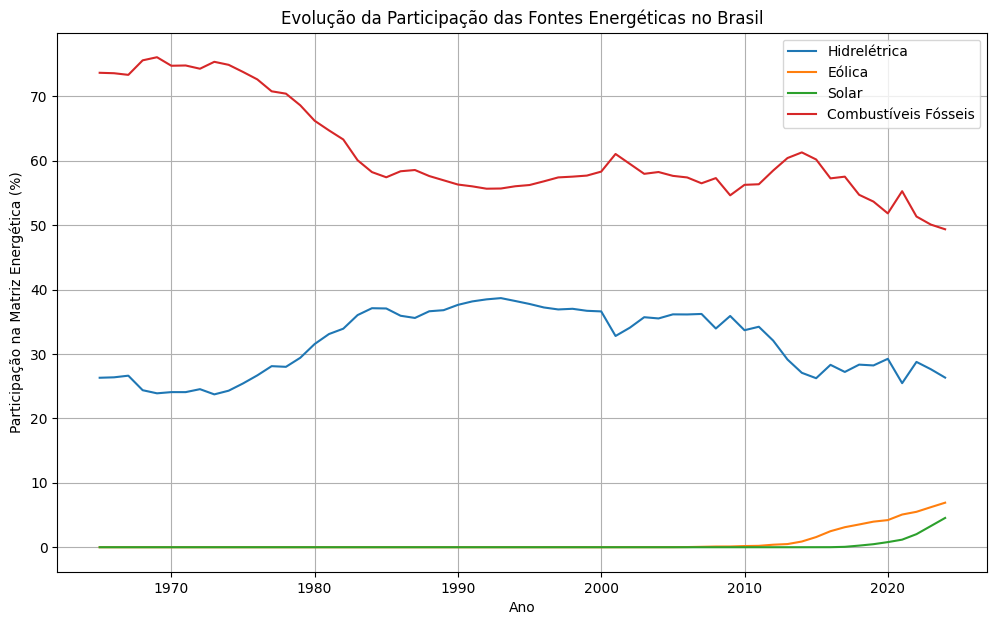

In [85]:
# cria o gráfico de linhas com a comparação
plt.figure(figsize=(12, 7))

plt.plot(
    brasil_fontes['year'],
    brasil_fontes['hydro_share_energy'],
    label='Hidrelétrica'
)


plt.plot(
    brasil_fontes['year'],
    brasil_fontes['wind_share_energy'],
    label='Eólica'
)

plt.plot(
    brasil_fontes['year'],
    brasil_fontes['solar_share_energy'],
    label='Solar'
)

plt.plot(
    brasil_fontes['year'],
    brasil_fontes['fossil_share_energy'],
    label='Combustíveis Fósseis'
)

plt.title('Evolução da Participação das Fontes Energéticas no Brasil')
plt.xlabel('Ano')
plt.ylabel('Participação na Matriz Energética (%)')
plt.legend()
plt.grid(True)

plt.show()


## **Pergunta 10** – A adoção de energias renováveis ocorre de forma homogênea entre os países ou está concentrada em casos específicos?

In [86]:
# utiliza a média de participação de energias renováveis por país (que foi calculada anteriormente) para analisar a distribuição entre os países.

# agrupa os dados por país
dados_por_pais = df_matriz.groupby('country')

# calcula a média de energia renovável para cada país
media_renovavel_por_pais = dados_por_pais['renewables_share_energy'].mean()

# mostra o resultado
media_renovavel_por_pais.head()


,renewables_share_energy
country,
Africa,7.119067
Africa (EI),7.119067
Algeria,0.849617
Argentina,8.876133
Asia,6.010633


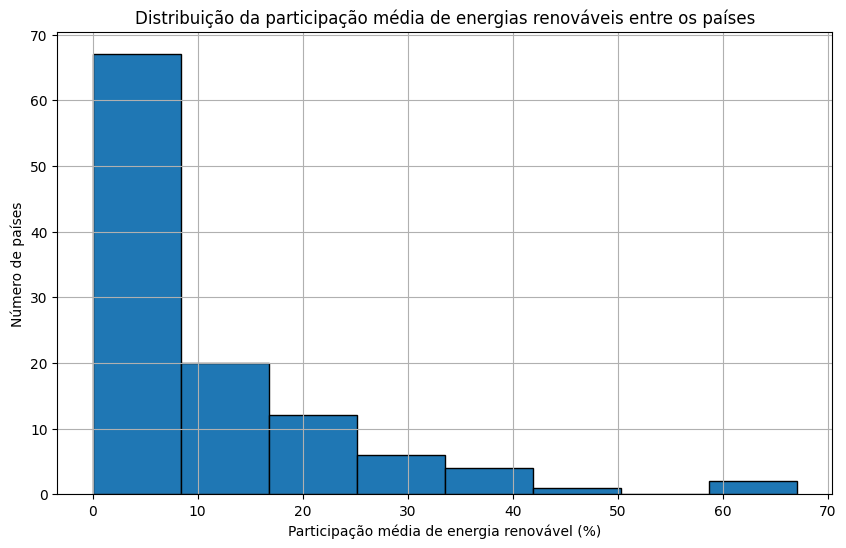

In [87]:
# cria o gráfico histograma para verificar a distribuição entre os países
plt.figure(figsize=(10, 6))
plt.hist(
    media_paises['renewables_share_energy'],
    bins=8,
    edgecolor='black'
)

plt.xlabel('Participação média de energia renovável (%)')
plt.ylabel('Número de países')
plt.title('Distribuição da participação média de energias renováveis entre os países')
plt.grid(True)
plt.show()
